In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


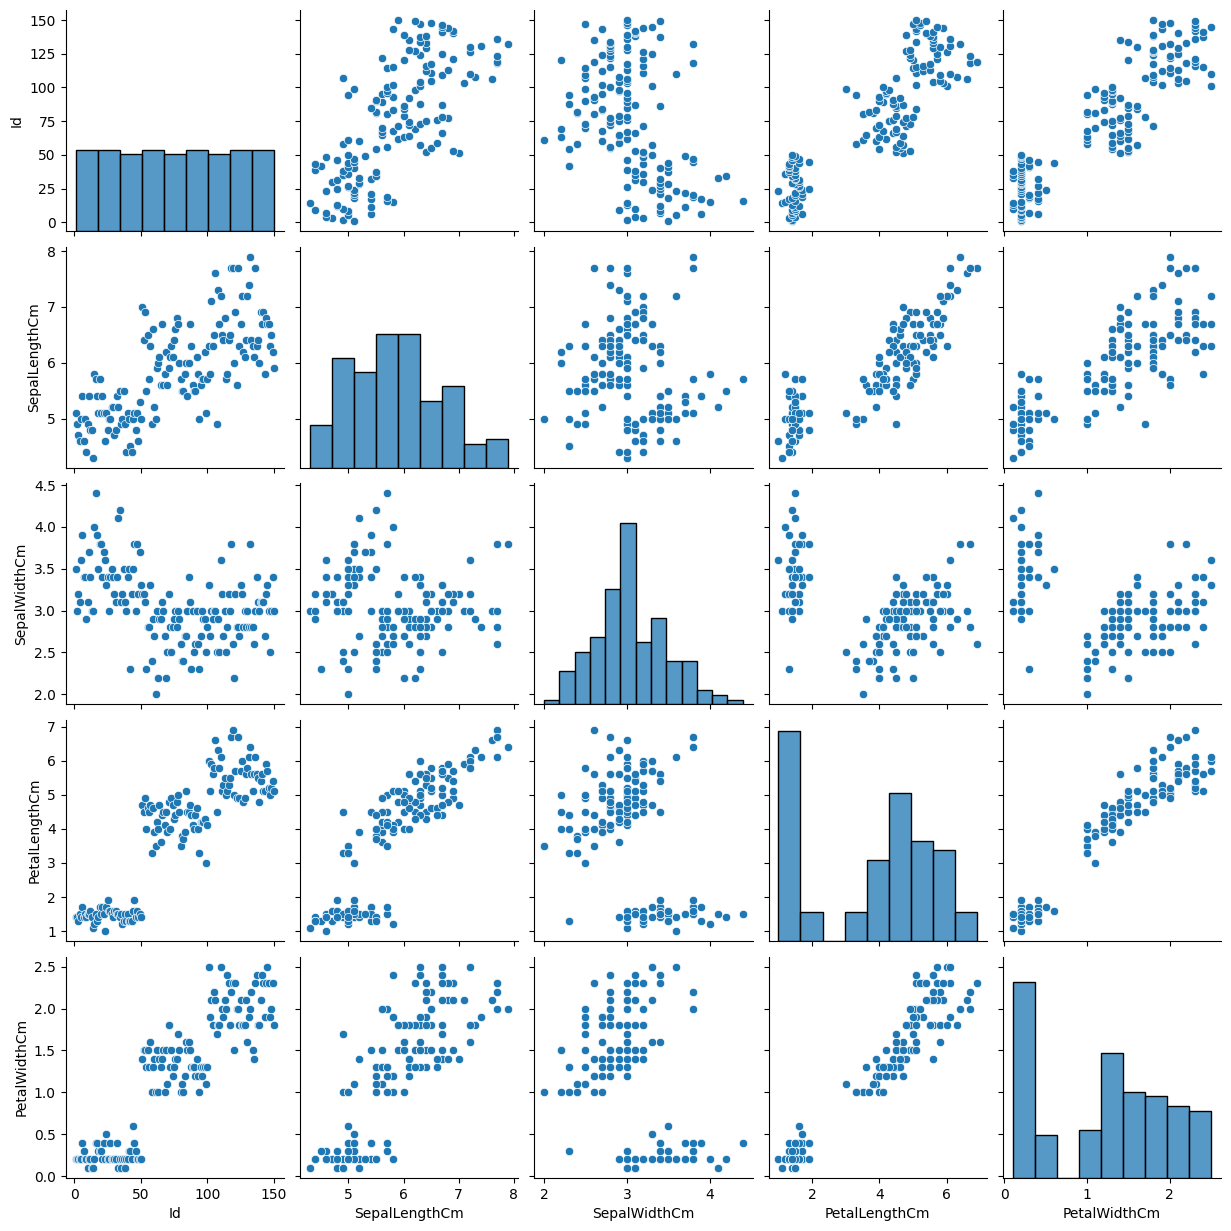

In [7]:
sns.pairplot(df)
plt.show()

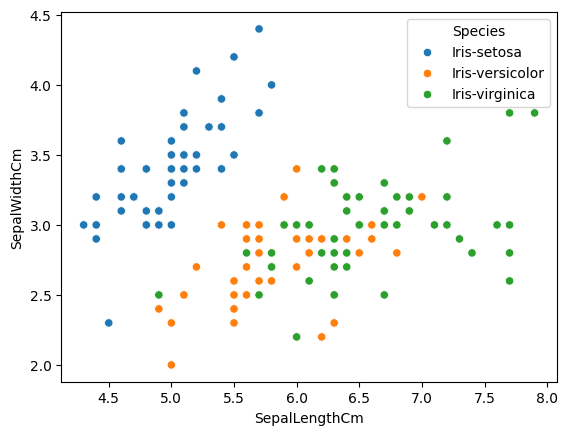

In [8]:
sns.scatterplot(x=df["SepalLengthCm"],y = df["SepalWidthCm"], hue = df["Species"])
plt.show()

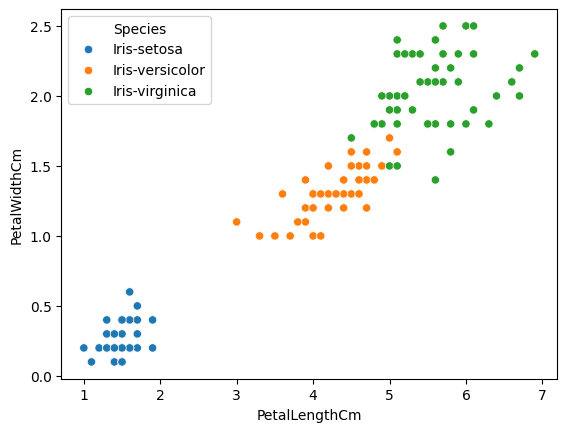

In [9]:
sns.scatterplot(x=df["PetalLengthCm"],y = df["PetalWidthCm"], hue = df["Species"])
plt.show()

In [10]:
df = df.drop("Id", axis = 1)

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])

In [13]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = df.drop("Species", axis = 1)
y = df["Species"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Prediction with Gaussian Naive Bayes

In [22]:
from sklearn.naive_bayes import GaussianNB

In [23]:
gnb = GaussianNB()

In [24]:
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
print("Confusion Matrix: \n", confusion_matrix(y_pred,y_test))
print("Accuracy Score: ", accuracy_score(y_pred,y_test))
print("Classification Report \n", classification_report(y_pred,y_test))

Confusion Matrix: 
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]
Accuracy Score:  1.0
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [27]:
# Prediction with LogisticRegression

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
logistic = LogisticRegression()
logistic.fit(X_train_scaled, y_train)
y_pred = logistic.predict(X_test_scaled)

In [30]:
print("Confusion Matrix: \n", confusion_matrix(y_pred,y_test))
print("Accuracy Score: ", accuracy_score(y_pred,y_test))
print("Classification Report \n", classification_report(y_pred,y_test))

Confusion Matrix: 
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]
Accuracy Score:  1.0
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [31]:
# Prediction with SVM

In [32]:
from sklearn.svm import SVC

In [33]:
SVC()

SVC()

In [34]:
param_grid = {
    "C" : [0.1, 1, 10, 100, 1000],
    "kernel" : ["rbf"],
    "gamma" : ["scale","auto"]
}

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid,cv=5)

In [37]:
grid.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 'auto'], 'kernel': ['rbf']})

In [38]:
grid.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [39]:
y_pred = grid.predict(X_test_scaled)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]
